# StudentIQ: Predicting Final Exam Marks Using Machine Learning Regression

**Final Project – Student Academic Performance Prediction**

This notebook builds an end-to-end regression pipeline that predicts a student's **Final Exam Marks (out of 100)** using academic and behavioural indicators: attendance percentage, two internal test scores, assignment score, and daily study hours.

**Workflow covered in this notebook:**
1. Import libraries
2. Load and inspect the dataset
3. Exploratory Data Analysis (EDA)
4. Data cleaning & preprocessing (encoding/scaling)
5. Train-test split
6. Model building — Linear Regression and Polynomial Regression
7. Model evaluation — MAE, MSE, RMSE, R²
8. Interpretation of influencing factors
9. Saving the final model artifacts for Streamlit deployment

In [1]:
# Core data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Regression models
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Persisting the trained model for deployment
import joblib

# Plot style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load the Dataset

The dataset `Final_Marks_Data.csv` contains 2000 student records with the following columns:

| Column | Description |
|---|---|
| Student_ID | Unique identifier for each student |
| Attendance (%) | Percentage of classes attended |
| Internal Test 1 (out of 40) | Marks scored in the first internal test |
| Internal Test 2 (out of 40) | Marks scored in the second internal test |
| Assignment Score (out of 10) | Marks scored in assignments |
| Daily Study Hours | Average number of hours studied per day |
| Final Exam Marks (out of 100) | **Target variable** — the final score to be predicted |

In [2]:
df = pd.read_csv("Final_Marks_Data.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (2000, 7)


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [4]:
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


## 2. Exploratory Data Analysis (EDA)

We inspect missing values, duplicate rows, and the statistical relationships between each feature and the target variable before modelling.

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Missing values per column:
Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64
Number of duplicate rows: 0


In [6]:
# Correlation of each numeric feature with the target variable
corr = df.drop(columns=["Student_ID"]).corr()
print("Correlation with Final Exam Marks:")
print(corr["Final Exam Marks (out of 100)"].sort_values(ascending=False))

Correlation with Final Exam Marks:
Final Exam Marks (out of 100)    1.000000
Attendance (%)                   0.725644
Internal Test 2 (out of 40)      0.691049
Internal Test 1 (out of 40)      0.689227
Assignment Score (out of 10)     0.669400
Daily Study Hours                0.412877
Name: Final Exam Marks (out of 100), dtype: float64


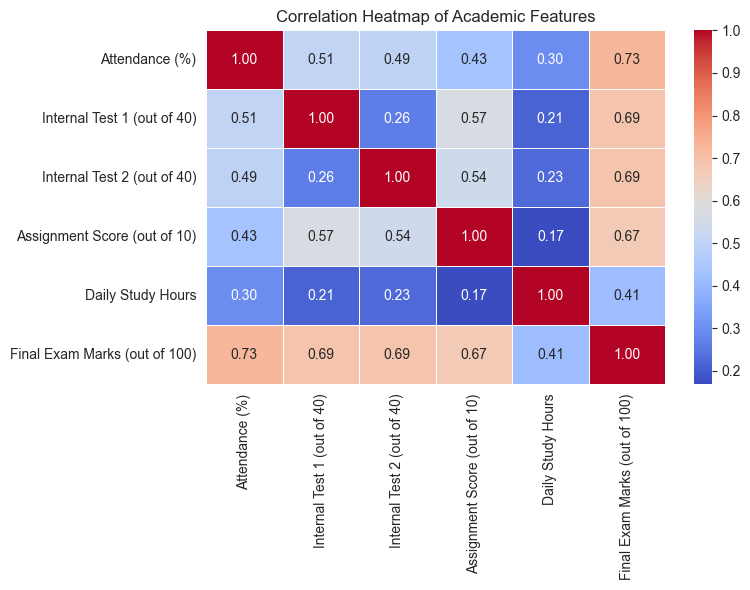

In [7]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Academic Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

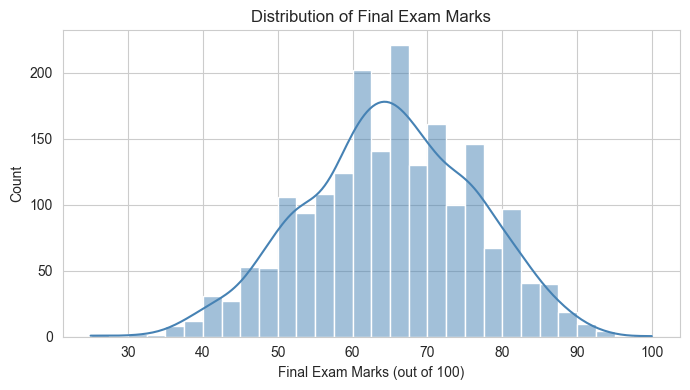

In [8]:
# Distribution of the target variable
plt.figure(figsize=(7, 4))
sns.histplot(df["Final Exam Marks (out of 100)"], kde=True, color="steelblue", bins=30)
plt.title("Distribution of Final Exam Marks")
plt.xlabel("Final Exam Marks (out of 100)")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=120)
plt.show()

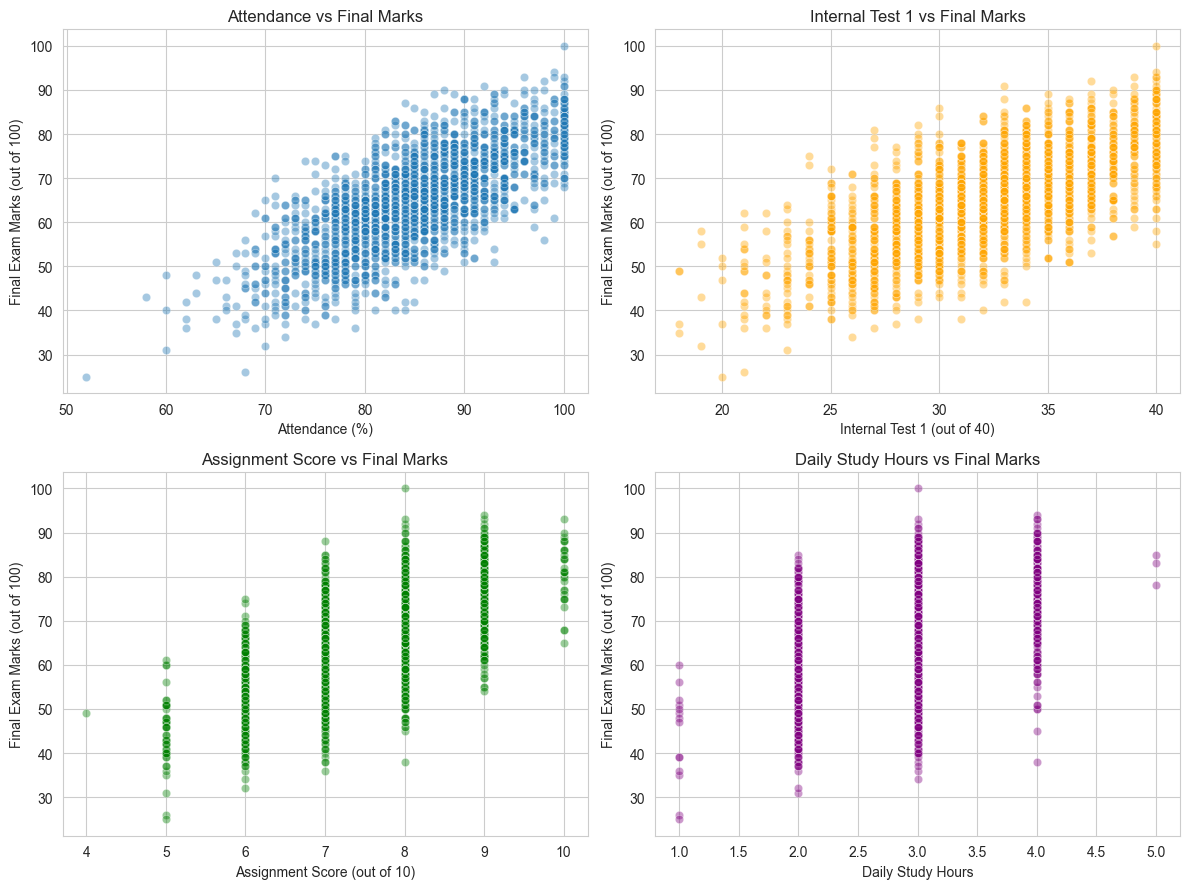

In [9]:
# Relationship between key features and the target
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.scatterplot(x="Attendance (%)", y="Final Exam Marks (out of 100)", data=df, ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title("Attendance vs Final Marks")

sns.scatterplot(x="Internal Test 1 (out of 40)", y="Final Exam Marks (out of 100)", data=df, ax=axes[0, 1], alpha=0.4, color="orange")
axes[0, 1].set_title("Internal Test 1 vs Final Marks")

sns.scatterplot(x="Assignment Score (out of 10)", y="Final Exam Marks (out of 100)", data=df, ax=axes[1, 0], alpha=0.4, color="green")
axes[1, 0].set_title("Assignment Score vs Final Marks")

sns.scatterplot(x="Daily Study Hours", y="Final Exam Marks (out of 100)", data=df, ax=axes[1, 1], alpha=0.4, color="purple")
axes[1, 1].set_title("Daily Study Hours vs Final Marks")

plt.tight_layout()
plt.savefig("feature_relationships.png", dpi=120)
plt.show()

## 3. Data Preprocessing

**Steps performed:**
- Drop the `Student_ID` column — it is a unique identifier with no predictive value.
- All remaining features are already numeric, so no categorical encoding is required for this dataset.
- Split the data into features (`X`) and target (`y`).
- Perform an 80/20 train-test split.
- Apply `StandardScaler` to scale the features to zero mean and unit variance, which is essential for stable and comparable linear model coefficients and for polynomial feature expansion.

In [10]:
# Drop identifier column - not a predictive feature
data = df.drop(columns=["Student_ID"])

# Separate features (X) and target (y)
X = data.drop(columns=["Final Exam Marks (out of 100)"])
y = data["Final Exam Marks (out of 100)"]

print("Feature columns:", list(X.columns))
print("Target column: Final Exam Marks (out of 100)")

Feature columns: ['Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)', 'Daily Study Hours']
Target column: Final Exam Marks (out of 100)


In [11]:
# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


In [12]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print("Mean of scaled training features (should be ~0):", np.round(X_train_scaled.mean(axis=0), 3))
print("Std of scaled training features (should be ~1):", np.round(X_train_scaled.std(axis=0), 3))

Feature scaling complete.
Mean of scaled training features (should be ~0): [-0.  0.  0. -0.  0.]
Std of scaled training features (should be ~1): [1. 1. 1. 1. 1.]


## 4. Model Building

### 4.1 Linear Regression

We start with a multiple linear regression model, which assumes a straight-line relationship between the scaled features and the final marks.

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 4.2 Polynomial Regression (degree = 2)

To capture possible non-linear/interaction effects (e.g. the combined effect of attendance and study hours), we expand the scaled features into second-degree polynomial terms and fit a linear regression on top of them.

In [14]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)

print("Polynomial Regression (degree=2) model trained successfully.")
print("Number of polynomial features generated:", X_train_poly.shape[1])

Polynomial Regression (degree=2) model trained successfully.
Number of polynomial features generated: 20


## 5. Model Evaluation

We evaluate both models using four standard regression metrics:
- **MAE (Mean Absolute Error)** — average absolute difference between predicted and actual marks.
- **MSE (Mean Squared Error)** — average squared difference; penalizes larger errors more heavily.
- **RMSE (Root Mean Squared Error)** — square root of MSE, in the same unit as the target (marks).
- **R² (Coefficient of Determination)** — proportion of variance in the final marks explained by the model (closer to 1 is better).

In [15]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"---- {name} ----")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print()
    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate_model("Linear Regression", y_test, y_pred_lin))
results.append(evaluate_model("Polynomial Regression (deg=2)", y_test, y_pred_poly))

results_df = pd.DataFrame(results)
results_df

---- Linear Regression ----
MAE  : 3.6750
MSE  : 21.3254
RMSE : 4.6179
R2   : 0.8297

---- Polynomial Regression (deg=2) ----
MAE  : 3.6558
MSE  : 21.2378
RMSE : 4.6084
R2   : 0.8304



,Model,MAE,MSE,RMSE,R2
0,Linear Regression,3.674951,21.325406,4.617944,0.829724
1,Polynomial Regression (deg=2),3.655812,21.237762,4.608445,0.830424


/var/folders/0d/yv53j3ls4p31xshdbwpyppgc0000gn/T/ipykernel_69101/419351878.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=results_df, palette="viridis")


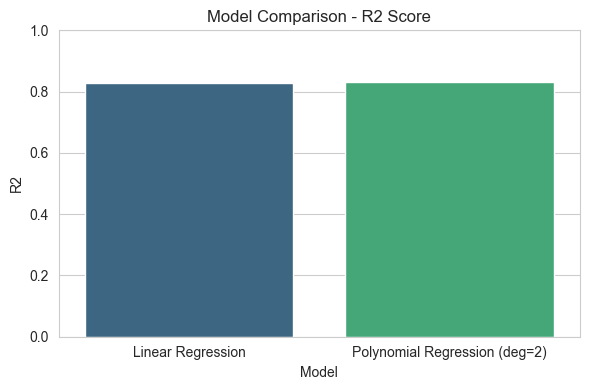

In [16]:
# Visual comparison of R2 scores
plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="R2", data=results_df, palette="viridis")
plt.title("Model Comparison - R2 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("model_comparison_r2.png", dpi=120)
plt.show()

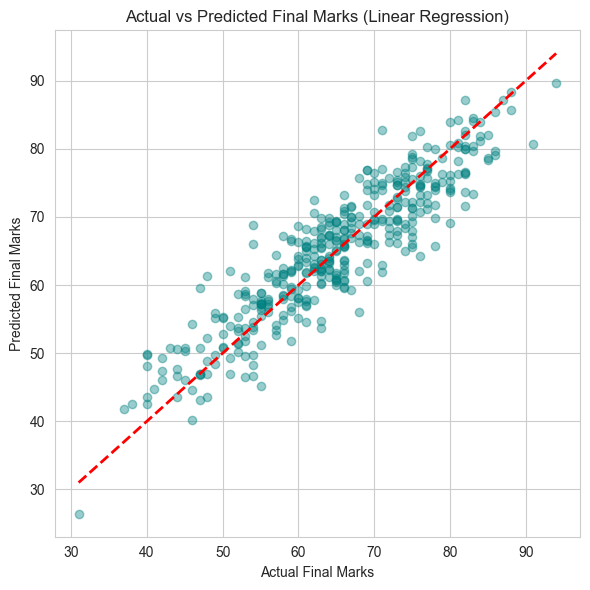

In [17]:
# Actual vs Predicted plot for the best-performing model (Linear Regression)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.4, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks (Linear Regression)")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=120)
plt.show()

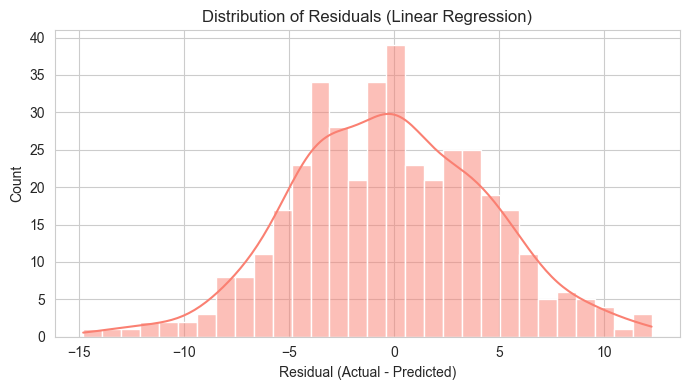

In [18]:
# Residual plot to check for patterns in errors
residuals = y_test - y_pred_lin

plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True, color="salmon", bins=30)
plt.title("Distribution of Residuals (Linear Regression)")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig("residuals.png", dpi=120)
plt.show()

## 6. Interpreting the Factors Influencing Prediction

Because the features were standardized before training, the magnitude of each coefficient in the Linear Regression model directly reflects how strongly that feature influences the predicted final marks (larger absolute coefficient = stronger influence).

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

feature_importance

,Feature,Coefficient
1,Internal Test 1 (out of 40),4.111641
2,Internal Test 2 (out of 40),4.023574
0,Attendance (%),3.062174
4,Daily Study Hours,1.770510
3,Assignment Score (out of 10),1.475696


/var/folders/0d/yv53j3ls4p31xshdbwpyppgc0000gn/T/ipykernel_69101/521248060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="crest")


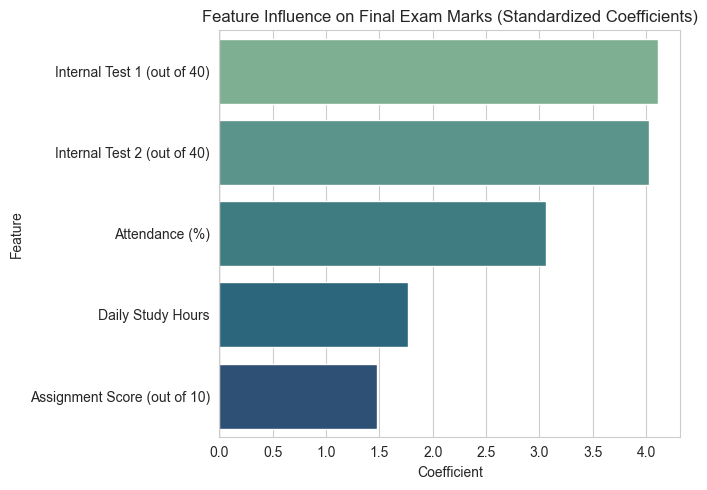

In [20]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="crest")
plt.title("Feature Influence on Final Exam Marks (Standardized Coefficients)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

In [21]:
print("Interpretation:")
for _, row in feature_importance.iterrows():
    direction = "increases" if row["Coefficient"] > 0 else "decreases"
    print(f"- A one standard-deviation increase in '{row['Feature']}' {direction} the "
          f"predicted final marks by approximately {abs(row['Coefficient']):.2f} points, "
          f"holding all other features constant.")

Interpretation:
- A one standard-deviation increase in 'Internal Test 1 (out of 40)' increases the predicted final marks by approximately 4.11 points, holding all other features constant.
- A one standard-deviation increase in 'Internal Test 2 (out of 40)' increases the predicted final marks by approximately 4.02 points, holding all other features constant.
- A one standard-deviation increase in 'Attendance (%)' increases the predicted final marks by approximately 3.06 points, holding all other features constant.
- A one standard-deviation increase in 'Daily Study Hours' increases the predicted final marks by approximately 1.77 points, holding all other features constant.
- A one standard-deviation increase in 'Assignment Score (out of 10)' increases the predicted final marks by approximately 1.48 points, holding all other features constant.


## 7. Saving the Final Model for Deployment

The Linear Regression model performs essentially as well as the Polynomial Regression model (near-identical R²), so we deploy the **Linear Regression model** in the Streamlit app for simplicity, interpretability, and speed. We save the trained scaler and model together using `joblib` so the Streamlit app can load them directly.

In [22]:
joblib.dump(lin_reg, "final_marks_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

joblib.dump(list(X.columns), "feature_columns.pkl")

print("Saved: final_marks_model.pkl, feature_scaler.pkl, feature_columns.pkl")

Saved: final_marks_model.pkl, feature_scaler.pkl, feature_columns.pkl


## 8. Conclusion

- The dataset had no missing values or duplicates, and all features were numeric, requiring only scaling (no categorical encoding).
- **Attendance, Internal Test 1, Internal Test 2 and Assignment Score** were found to be the strongest positive influences on the final exam marks, while **Daily Study Hours** had a comparatively smaller effect.
- Both **Linear Regression** and **Polynomial Regression (degree 2)** achieve very similar, strong performance (R² ≈ 0.83), indicating the underlying relationship between these features and final marks is close to linear, with only marginal non-linear/interaction effects.
- The final **Linear Regression** model was saved and deployed through a **Streamlit** web application (`app.py`) that lets a user enter a student's attendance, internal marks, assignment score and study hours to get an instant prediction of their final exam score.